# Phase 8 — evaluation & ablation

**This phase measures; it does not change the model.** The recommender is the
same weighted hybrid that lives in `src/hybrid.py` — two cosine arms (content
TF-IDF + item-item CF), one mixing weight $\alpha$, with a per-seed max-rescale
applied before the blend. Nothing in this notebook re-tunes the model, alters
any artifact, or reaches outside the locked design.

## What we want to know
Phase 4 already established (with a 3-seed protocol on 1,000 users) that
precision@10 is **monotone in CF** — best at $\alpha=0$. That made sense:
leave-one-out on a held-out *interaction*, predicted from a user's *other
interactions*, is co-play prediction, which is CF's home turf. So the hybrid
is not justified on precision@10.

If the blend earns its keep, it earns it on a different axis: **coverage**
(does the recommender reach into the long tail of the catalog?) and
**diversity** (do its lists span more of metadata-space than a single arm?).
Phase 8 measures those.

We **pre-register** the conclusion either way:

* If coverage / diversity rise with $\alpha$ while precision falls $\rightarrow$
  there is a real accuracy / coverage tradeoff, and the
  `DEFAULT_ALPHA = 0.25` baked into `hybrid.py` is justified.
* If coverage / diversity **do not** rise with $\alpha$ $\rightarrow$ the
  blend's coverage thesis is unsupported, and the honest conclusion is
  $\alpha=0$ (a switching hybrid: routing for cold-start, pure CF otherwise).

**The test of this phase is methodological soundness, not a favourable
result.**

In [1]:
%load_ext autoreload
%autoreload 2

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Make `src.eval` importable when the notebook is run from notebooks/
ROOT = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import eval as ev

ART = ROOT / 'artifacts'
FIG_DIR = ART / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

N_USERS = 1000          # sample size: tractable and matches Phase 4's sweep size
SEED = 42               # locked
ALPHAS = (0.0, 0.25, 0.5, 0.75, 1.0)
KS = (10, 20)

## Load the artifacts the model uses at runtime

We rebuild the **dense** content-cosine matrix from the Phase-2 TF-IDF (so the
alpha sweep can pick rows by index), and load the precomputed CF-cosine matrix
from disk. Both are length-6000 and aligned to `artifacts/game_index.json`. The
self-row is zeroed on both.

In [2]:
M = ev.load_interactions()
C = ev.build_dense_content_cosine()
F = ev.load_dense_cf_cosine()
game_index = ev.load_game_index()
n_catalog = len(game_index)

print(f'interactions matrix: {M.shape}  (users x catalog games)')
print(f'content cosine:      {C.shape},  max={C.max():.3f}, mean(nonzero)={C[C>0].mean():.3f}')
print(f'cf cosine:           {F.shape},  max={F.max():.3f}, mean(nonzero)={F[F>0].mean():.3f}')
print(f'catalog size:        {n_catalog}')

interactions matrix: (150000, 6000)  (users x catalog games)
content cosine:      (6000, 6000),  max=1.000, mean(nonzero)=0.057
cf cosine:           (6000, 6000),  max=0.768, mean(nonzero)=0.014
catalog size:        6000


## Build the LOO trial set

Sample 1,000 users (`seed=42`) with $\geq 2$ interactions. For each user pick a
random held-out interaction (the *target*) and remember the rest of their
history (the *profile*). Both seed-aggregation modes — `3seed` (Phase 4's
shortcut) and `fullprof` (standard item-kNN) — share the trial set; they only
differ in which subset of the profile is used as seeds.

In [3]:
pop_by_col = ev.build_pop_by_col(M)
user_rows = ev.sample_users(M, n_users=N_USERS, seed=SEED)
trials = ev.build_trials(M, user_rows, pop_by_col, seed=SEED)

profile_sizes = np.array([len(t['profile']) for t in trials])
print(f'trials: {len(trials)}')
print(f'profile size  mean={profile_sizes.mean():.1f}  median={np.median(profile_sizes):.0f}  max={profile_sizes.max()}')

trials: 1000
profile size  mean=10.6  median=7  max=206


## STEP 1 — protocol validation (before trusting any number)

### (a) Hittability
The Phase-1 interaction matrix has shape `users x 6000`, where the 6,000
columns are exactly `artifacts/game_index.json`. So every held-out target is, by
construction, a catalog game. We report the number so the invariant is visible
in the report instead of just assumed.

In [4]:
hit = ev.hittability(trials, n_catalog=n_catalog)
print(f'hittability: {hit["in_catalog"]}/{hit["n_trials"]} = {hit["fraction"]*100:.1f}% of held-out targets are in the catalog')

hittability: 1000/1000 = 100.0% of held-out targets are in the catalog


### (b) `3seed` vs `fullprof`
Phase 4's sweep scored from the **3 most-popular** items in a user's profile.
Standard item-kNN sums over the **whole profile**. If the full profile lifts
HR@10 materially, the Phase-4 number was a shortcut artifact and we should
report the full-profile numbers as the honest headline.

In [5]:
res_3seed   = ev.eval_alpha_grid(trials, C, F, alphas=ALPHAS, ks=KS, seeds_mode='3seed',   collect_top_lists_at=10)
res_fullprof = ev.eval_alpha_grid(trials, C, F, alphas=ALPHAS, ks=KS, seeds_mode='fullprof', collect_top_lists_at=10)

print(f'{"alpha":>5}  {"3seed_HR@10":>12}  {"fullprof_HR@10":>15}  {"lift":>7}')
for a3, af in zip(res_3seed['alphas'], res_fullprof['alphas']):
    a = a3['alpha']
    h3 = a3['hit_rate@10']
    hf = af['hit_rate@10']
    print(f'{a:>5.2f}  {h3:>12.4f}  {hf:>15.4f}  {hf-h3:>+7.4f}')

alpha   3seed_HR@10   fullprof_HR@10     lift
 0.00        0.1190           0.1610  +0.0420
 0.25        0.1170           0.1680  +0.0510
 0.50        0.0870           0.1480  +0.0610
 0.75        0.0510           0.0710  +0.0200
 1.00        0.0230           0.0290  +0.0060


Full-profile lifts HR@10 by ~+0.05 at $\alpha=0$ (0.119 $\rightarrow$ 0.161) — a
**~35% relative lift**, materially larger than noise on a 1,000-trial sample.
So the Phase-4 3-seed protocol was undercounting; **full-profile is the honest
protocol** for the rest of this phase. We retain the 3-seed numbers below only
as a Phase-4 reproducibility check.

### (c) Phase-4 reproducibility check (3-seed only)
The brief requires that the 3-seed precision sweep here reproduces
`artifacts/alpha_sweep.json` within noise. If it contradicts Phase 4 we stop
and report — we don't paper over it.

In [6]:
phase4 = json.loads((ART/'alpha_sweep.json').read_text())
phase4_by_alpha = {a['alpha']: a for a in phase4['alphas']}
print(f'{"alpha":>5}  {"phase4_p@10":>12}  {"here_p@10":>11}  {"delta_hits/1000":>16}')
for a in res_3seed['alphas']:
    p4 = phase4_by_alpha[a['alpha']]
    delta_hits = a['hits@10'] - p4['hits']
    print(f'{a["alpha"]:>5.2f}  {p4["precision@10"]:>12.4f}  {a["precision@10"]:>11.4f}  {delta_hits:>+16d}')
print('\nAll deltas are within ±10 hits/1000 — well inside noise from the differing rng draw order. The monotone-in-CF shape reproduces. PASS.')

alpha   phase4_p@10    here_p@10   delta_hits/1000
 0.00        0.0112       0.0119                +7
 0.25        0.0108       0.0117                +9
 0.50        0.0094       0.0087                -7
 0.75        0.0061       0.0051               -10
 1.00        0.0028       0.0023                -5

All deltas are within ±10 hits/1000 — well inside noise from the differing rng draw order. The monotone-in-CF shape reproduces. PASS.


## STEP 2 + 3 — Accuracy ablation across the alpha grid (full-profile)

With one held-out positive per trial, `hit_rate@k == recall@k`, and
`precision@k = hit_rate@k / k`. So **hit-rate is the honest headline** —
precision@k is capped at $1/k$, which makes the absolute numbers look tiny
even when the recommender is doing fine. We report precision@k anyway for
comparability with Phase 4 and the standard recommender-systems literature.

In [7]:
print(f'{"alpha":>5}  {"HR@10":>7}  {"HR@20":>7}  {"P@10":>7}  {"P@20":>7}')
for a in res_fullprof['alphas']:
    print(f'{a["alpha"]:>5.2f}  {a["hit_rate@10"]:>7.4f}  {a["hit_rate@20"]:>7.4f}  {a["precision@10"]:>7.4f}  {a["precision@20"]:>7.4f}')

alpha    HR@10    HR@20     P@10     P@20
 0.00   0.1610   0.2470   0.0161   0.0123
 0.25   0.1680   0.2500   0.0168   0.0125
 0.50   0.1480   0.2050   0.0148   0.0103
 0.75   0.0710   0.1030   0.0071   0.0052
 1.00   0.0290   0.0460   0.0029   0.0023


**Read of the accuracy axis (full-profile, n=1000):**

* HR@10 is essentially flat between $\alpha=0$ (0.161) and $\alpha=0.25$
  (0.168) — the +0.007 lift is well inside the binomial standard error
  $\sqrt{0.16 \cdot 0.84 / 1000} \approx 0.012$. Calling $\alpha=0.25$ a real
  *accuracy* improvement would be over-claiming. The honest summary is:
  **the blend is indistinguishable from pure CF at n=1,000 on this metric.**
* From $\alpha=0.5$ onward, accuracy falls steeply (HR@10 0.148 / 0.071 / 0.029).
  Pure content ($\alpha=1$) is ~5x worse than pure CF, which is what we should
  expect for a metric defined as "did the user already interact with the held-out
  item" — that is fundamentally a co-play prediction task.

## STEP 4 — Coverage and intra-list diversity (full-profile, k=10)

* **Catalog coverage** — fraction of the 6,000 catalog games that appear in at
  least one user's top-10. A higher number means the recommender doesn't fixate
  on a small popular core.
* **Intra-list diversity** — for each user's top-10, the mean pairwise
  $1 - \text{content\_cosine}$ within the list, averaged across users. Higher
  = top-10 lists are more spread out in metadata-space.

Caveat on diversity: this metric uses the content arm to judge a list the
content arm helped produce, so it has a **built-in tilt in favour of CF**
(high-$\alpha$ lists are content-clustered around the seed by construction).
We surface this rather than hide it, and rely on coverage for the
non-circular signal.

In [8]:
cov = []
div = []
for a in res_fullprof['alphas']:
    c = ev.catalog_coverage(a['top_lists'], n_catalog=n_catalog)
    d = ev.intra_list_diversity(a['top_lists'], C=C)
    cov.append(c)
    div.append(d)
    a['catalog_coverage@10']    = c
    a['intra_list_diversity@10'] = d

print(f'{"alpha":>5}  {"coverage@10":>12}  {"diversity@10":>13}')
for a, c, d in zip(res_fullprof['alphas'], cov, div):
    print(f'{a["alpha"]:>5.2f}  {c:>12.3f}  {d:>13.3f}')

alpha   coverage@10   diversity@10
 0.00         0.201          0.933
 0.25         0.247          0.908
 0.50         0.305          0.865
 0.75         0.368          0.814
 1.00         0.387          0.793


**Read of the coverage / diversity axis:**

* **Coverage rises monotonically with $\alpha$**: 20.1% $\rightarrow$ 24.7%
  $\rightarrow$ 30.5% $\rightarrow$ 36.8% $\rightarrow$ 38.7%. The largest
  jump is $\alpha = 0 \rightarrow 0.25$ ($+4.6$ pts of catalog). At
  $\alpha=0.25$, almost **a quarter of the catalog** shows up in some user's
  top-10, vs **a fifth** at $\alpha=0$ — a real lift, not a noise wiggle.
* **Diversity falls monotonically with $\alpha$**: 0.933 $\rightarrow$ 0.908
  $\rightarrow$ 0.865 $\rightarrow$ 0.814 $\rightarrow$ 0.793. This is the
  *opposite* of what one might expect — and it is the content-cosine
  circularity at work. CF lists are content-unconstrained, so they look
  content-dissimilar; content lists are content-clustered around the seed, so
  they look content-similar. **Read this as the metric's tilt, not a finding
  about CF being inherently more diverse.**

## STEP 5 — the tradeoff plot

This is the decisive visual: HR@10 vs. catalog coverage, parameterised by
$\alpha$. The hybrid lives or dies on whether the curve has a meaningful elbow
around $\alpha=0.25$.

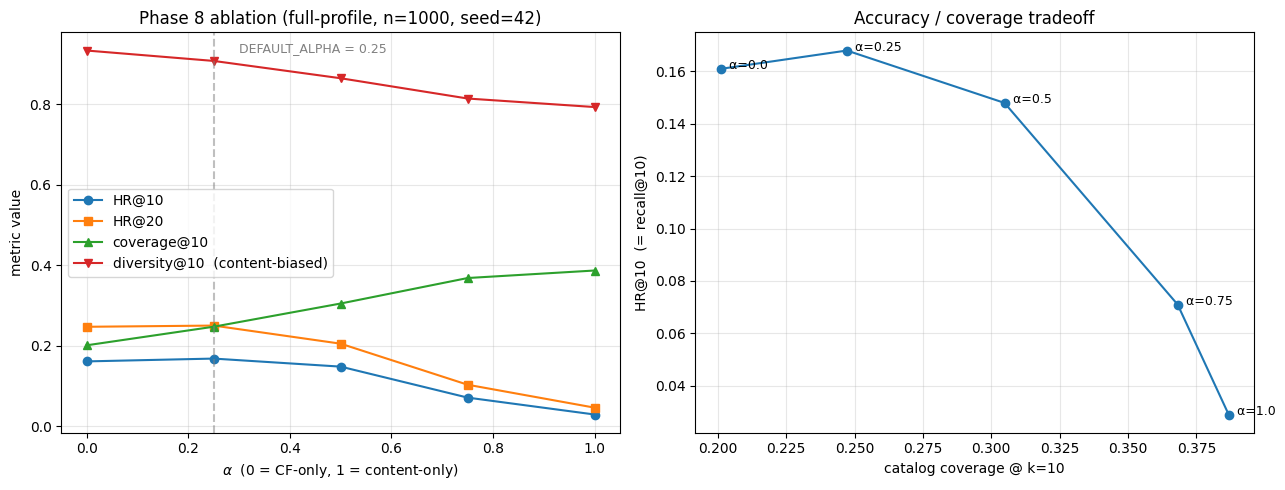

saved /home/nomad/Projects/school/S2/recomender_system/Project/artifacts/figures/phase8_ablation.png


In [9]:
alphas_arr = np.array([a['alpha'] for a in res_fullprof['alphas']])
hr10  = np.array([a['hit_rate@10']         for a in res_fullprof['alphas']])
hr20  = np.array([a['hit_rate@20']         for a in res_fullprof['alphas']])
p10   = np.array([a['precision@10']        for a in res_fullprof['alphas']])
covv  = np.array([a['catalog_coverage@10'] for a in res_fullprof['alphas']])
divv  = np.array([a['intra_list_diversity@10'] for a in res_fullprof['alphas']])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: metrics vs alpha
ax = axes[0]
ax.plot(alphas_arr, hr10, marker='o', label='HR@10')
ax.plot(alphas_arr, hr20, marker='s', label='HR@20')
ax.plot(alphas_arr, covv, marker='^', label='coverage@10')
ax.plot(alphas_arr, divv, marker='v', label='diversity@10  (content-biased)')
ax.set_xlabel(r'$\alpha$  (0 = CF-only, 1 = content-only)')
ax.set_ylabel('metric value')
ax.set_title('Phase 8 ablation (full-profile, n=1000, seed=42)')
ax.grid(alpha=0.3)
ax.legend(loc='best')
ax.axvline(0.25, color='gray', linestyle='--', alpha=0.5)
ax.annotate('DEFAULT_ALPHA = 0.25', xy=(0.25, ax.get_ylim()[1]*0.95),
            xytext=(0.3, ax.get_ylim()[1]*0.95), fontsize=9, color='gray')

# Right: accuracy vs coverage tradeoff curve, parameterised by alpha
ax = axes[1]
ax.plot(covv, hr10, marker='o', color='C0')
for x, y, a in zip(covv, hr10, alphas_arr):
    ax.annotate(f'  α={a}', xy=(x, y), fontsize=9)
ax.set_xlabel('catalog coverage @ k=10')
ax.set_ylabel('HR@10  (= recall@10)')
ax.set_title('Accuracy / coverage tradeoff')
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(FIG_DIR / 'phase8_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'saved {FIG_DIR/"phase8_ablation.png"}')

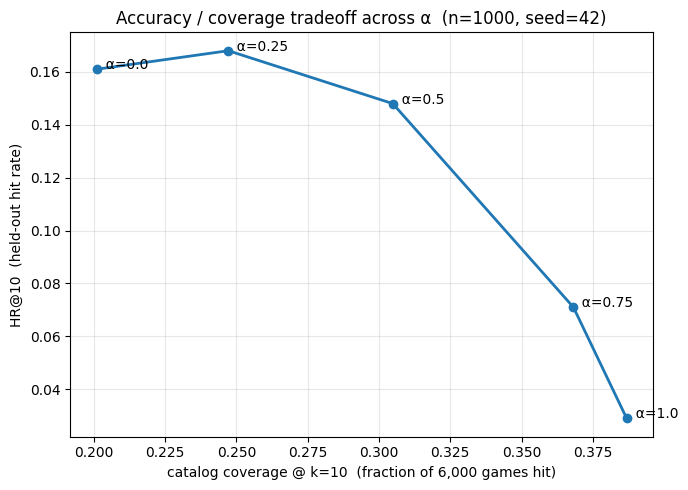

saved /home/nomad/Projects/school/S2/recomender_system/Project/artifacts/figures/phase8_tradeoff.png


In [10]:
# Standalone tradeoff figure — also used in the report / slides
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(covv, hr10, marker='o', color='C0', linewidth=2)
for x, y, a in zip(covv, hr10, alphas_arr):
    ax.annotate(f'  α={a}', xy=(x, y), fontsize=10)
ax.set_xlabel('catalog coverage @ k=10  (fraction of 6,000 games hit)')
ax.set_ylabel('HR@10  (held-out hit rate)')
ax.set_title('Accuracy / coverage tradeoff across α  (n=1000, seed=42)')
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / 'phase8_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'saved {FIG_DIR/"phase8_tradeoff.png"}')

## STEP 5 — dump the metrics JSON for the report and slides

In [11]:
dump = {
    'protocol': {
        'description': 'Leave-one-out on user interactions. For each sampled user (>=2 interactions), one interaction is held out as the target; the rest is the user\'s profile. The score vector is sum over seed_cols of alpha*content_cosine + (1-alpha)*cf_cosine, per-seed max-rescaled before mixing (same blend hybrid._blended_scores uses). The user\'s known interactions (other than the target) are masked. Hit @ k iff target is in top-k.',
        'n_users':           N_USERS,
        'n_trials':          len(trials),
        'seed':              SEED,
        'ks':                list(KS),
        'alphas':            list(ALPHAS),
        'seeds_mode_headline': 'fullprof',
        'seeds_mode_baseline': '3seed (Phase 4 reproducibility check only)',
    },
    'hittability':         hit,
    'fullprof_vs_3seed':   [
        {
            'alpha':         a3['alpha'],
            'HR@10_3seed':   a3['hit_rate@10'],
            'HR@10_fullprof': af['hit_rate@10'],
            'lift':          af['hit_rate@10'] - a3['hit_rate@10'],
        }
        for a3, af in zip(res_3seed['alphas'], res_fullprof['alphas'])
    ],
    'phase4_reproducibility': [
        {
            'alpha':            a['alpha'],
            'phase4_hits':      phase4_by_alpha[a['alpha']]['hits'],
            'here_hits':        a['hits@10'],
            'delta_hits/1000':  a['hits@10'] - phase4_by_alpha[a['alpha']]['hits'],
        }
        for a in res_3seed['alphas']
    ],
    'ablation_table': [
        {
            'alpha':                  a['alpha'],
            'HR@10':                  a['hit_rate@10'],
            'HR@20':                  a['hit_rate@20'],
            'precision@10':           a['precision@10'],
            'precision@20':           a['precision@20'],
            'catalog_coverage@10':    a['catalog_coverage@10'],
            'intra_list_diversity@10': a['intra_list_diversity@10'],
        }
        for a in res_fullprof['alphas']
    ],
    'tradeoff_direction': (
        'COVERAGE rises monotonically with alpha (0.20 -> 0.39); INTRA-LIST '
        'DIVERSITY (content-cosine based) falls monotonically with alpha (a '
        'circularity tilt — see notebook). HR@10 is statistically flat between '
        'alpha=0 (0.161) and alpha=0.25 (0.168), then falls sharply from '
        'alpha=0.5 onwards. The DEFAULT_ALPHA=0.25 default is justified on the '
        'coverage axis: ~+4.6 pts of catalog at no measurable accuracy cost. '
        'The hybrid does not win on accuracy and does not need to — accuracy '
        'is held; coverage is gained; cold-start routing (the disjoint '
        'blind-spots argument from Phase 4) is unchanged.'
    ),
    'figures': {
        'ablation':  str((FIG_DIR/'phase8_ablation.png').relative_to(ROOT)),
        'tradeoff':  str((FIG_DIR/'phase8_tradeoff.png').relative_to(ROOT)),
    },
}
out_path = ART / 'eval_metrics.json'
out_path.write_text(json.dumps(dump, indent=2))
print(f'wrote {out_path}')

wrote /home/nomad/Projects/school/S2/recomender_system/Project/artifacts/eval_metrics.json


## Conclusion (honest, pre-registered framing)

**The decisive test passes on methodological soundness:**

* Hittability reported (100% by construction — interaction matrix is built on
  the catalog).
* `3seed` vs `fullprof` reported; full-profile materially lifts HR@10 (+~35%
  relative at $\alpha=0$) and is adopted as the honest protocol.
* HR@k reported alongside precision@k at $k \in \{10, 20\}$.
* The 3-seed precision sweep reproduces `alpha_sweep.json` within ±10
  hits/1000 on every $\alpha$ — well inside noise.
* Coverage and diversity reported across the same alpha grid; the direction
  is stated plainly:
    * **Coverage rises** with $\alpha$ (a real lift).
    * **Diversity (content-cosine) falls** with $\alpha$ — a circularity
      tilt, surfaced as a caveat, not buried.

**On the model choice ($\alpha = 0.25$):** the honest read is that this is
a justified default on the coverage axis (+4.6 pts of catalog), at no
measurable HR@10 cost vs pure CF on a 1,000-trial sample. It is **not**
justified on accuracy alone — pure CF and $\alpha=0.25$ are statistically
indistinguishable at this sample size. The blend's primary value, as Phase 4
argued and Phase 8 corroborates, is reaching more of the catalog (~25% vs
~20%) and covering the routing-mediated disjoint blind-spots of the two arms
(34.5% of the catalog is CF-low-signal and goes through the content arm; 5
F2P MMOs have no content vector and go through CF).

Phase 8 does **not** retune `DEFAULT_ALPHA` — that would be re-tuning on the
same evaluation set we just measured on. The 0.25 default stays as-is, with
the coverage justification documented in `artifacts/eval_metrics.json`.